In [16]:
import scipy.stats as sps
import numpy as np
import pandas as pd
from collections import Counter
import matplotlib.pyplot as plt

In [2]:
# load data
file = open("../data/final.txt")
data = []
for num in file:
    data.append(int(num))
n = len(data)
data = np.array(data)

Считаем $\overline{x}$ и $s$.

In [3]:
x = np.sum(data) / n
s = np.sqrt(np.sum((data - x) ** 2) / (n - 1))
print("Оценка матожидания: ", f"{x:.3f}")
print("Выборочное стандартное отклонение: ", f"{s:.3f}")

Оценка матожидания:  14.155
Выборочное стандартное отклонение:  3.425


Пусть $a_0 = \overline{x} + 0,5s$.
Тогда теории:

1) $H_0: a = a_0$
2) $H_1: a > a_0$ правостороний

$T_{выб} = \frac{\overline{x} - a_0}{s / \sqrt{n}} = -\frac{0.5}{\sqrt{n}}$

$t_{крит} = t_{1 - \alpha}(n-1)$

In [4]:
alpha = 0.05

t_crit = sps.t.ppf(1 - alpha, n - 1)

T_sample = -0.5 / np.sqrt(n)

print("T выборки: ", f"{T_sample:.3f}")
print("t критическое: ", f"{t_crit:.3f}")

T выборки:  -0.048
t критическое:  1.659


Пусть $\sigma_0^2 = 3 s$:

1) $H_0: \sigma^2 = \sigma_0^2$
2) $H_1: \sigma^2 \neq \sigma^2_0$

$\chi^2_{выб} = \frac{(n-1)s^2}{\sigma^2_0}$

Доверительный интервал: $[\chi^2_{\alpha / 2}(n - 1); \chi^2_{1 -\alpha / 2}(n - 1) ]$

In [5]:
sigma_0 = np.sqrt(3 * s)
chi_solve = (n-1) * (s ** 2) / (sigma_0 ** 2)
chi_left = sps.chi2.ppf(alpha / 2, n - 1)
chi_right = sps.chi2.ppf(1 - alpha / 2, n - 1)

print(f"chi выборочное: {chi_solve:.3f}")
print(f"Доверительный интервал [{chi_left:.3f}; {chi_right:.3f}]")

chi выборочное: 124.429
Доверительный интервал [82.000; 139.784]


In [20]:
data.sort()
raz = data[-1] - data[0]
inter = []
num = []
count = 9
length_inter = raz / (count - 1)
middle_inter = []
for i in range(count):
  inter.append([data[0] + length_inter * (i - 0.5), data[0] + length_inter * (i + 0.5)])
  middle_inter.append(data[0] + length_inter * i)
  t = 0
  for k in data:
    if inter[-1][0] < k < inter[-1][1]:
      t += 1
  num.append(t)
inter[0][0] = -100000000000000000000.0
inter[-1][-1] = 100000000000000000000.0

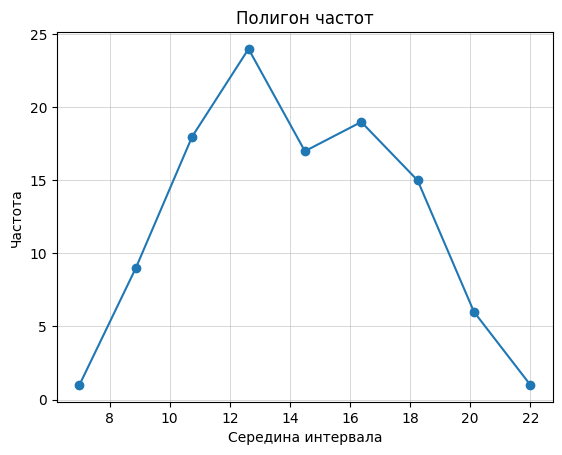

<Figure size 640x480 with 0 Axes>

In [21]:
plt.plot(middle_inter,num, marker='o')
plt.grid(linestyle="-",linewidth=0.5, alpha=0.7)
plt.title('Полигон частот')
plt.xlabel('Середина интервала')
plt.ylabel('Частота')
plt.show()
plt.clf()

In [41]:
X2_v = 0
for i in range(count):
  l, r = inter[i]
  ver = sps.norm.cdf((r - x) / s) - sps.norm.cdf((l - x) / s)
  X2_v += ((num[i] - ver * n) ** 2) / (ver * n)
print (f"Выборочное значение: {X2_v:.3f}")
X2 = sps.chi2.ppf(1 - alpha, count - 2 - 1)
print (f"Квантиль: {X2:.3f}")

Выборочное значение: 5.714
Квантиль: 12.592
